# 1. Definición del Problema y Estrategia de Modelado

Tras haber procesado nuestro datase durante la fase de Análisis Exploratorio de Datos, el objetivo de este notebook es construir, entrenar y evaluar un algoritmo de aprendizaje supervisado capaz de identificar el nivel de riesgo de la cartera hipotecaria. Optaremos por el desarrollo de una Red Neuronal Multicapa (MLP) utilizando el framework PyTorch, contrastando su desempeño contra una línea base estadística tradicional (Regresión Logística). Como primer paso describiremos explicitamente el problema debe resolver nuestro modelo supervisado y qué métricas priorizaremos para lograrlo.

## 1.1. Variable objetivo y Vector de características
Alineados al objetivo de gestión de riesgo de la NIFBdM C-16, definimos nuestro problema como una tarea de **clasificación multiclase**.
* Variable objetivo ($Y$): `etapa`. Representa el nivel de deterioro del crédito. Definimos el espacio de etiquetas como $Y \in \{1, 2, 3\}$, correspondientes a:
    * **Etapa 1 - Riesgo de crédito bajo o normal**: Son aquéllos por los que su riesgo de crédito no se ha incrementado significativamente desde su valuación inicial hasta la fecha de los estados financieros.
    * **Etapa 2 - Riesgo de crédito con incremento o significativo**: Son aquéllos que han mostrado un aumento significativo de riesgo de crédito desde su valuación inicial hasta la fecha de los estados financieros.
    * **Etapa 3 - Riesgo de cŕedito alto o default**: Son aquéllos con deterioro crediticio porque han ocurrido uno o más eventos que tienen un impacto perjudicial sobre los flujos de efectivo futuros del IFCPI.
* Vector de Características ($X$): Para cada cohorte $i$, definimos un vector de entrada $x^{(i)} \in \mathbb{R}^d$, donde $d$ es el número de dimensiones tras el preprocesamiento. Basados en nuestro EDA, este vector estará compuesto por las siguientes características:
    * Perfil del acreditado: `intervalo_edades`, `intervalo_ingreso_acreditado`, `sector_laboral`
    * Inmueble comercial: `estado`, `destino_credito`, `segmento_vivienda`
    * Estructura del cŕedito: `moneda`
    * Exposición financiera: `saldo_insoluto_final_periodo`, `tasa_ponderada`

El objetivo de nuestro modelo será aprender la función de mapeo $f: X \rightarrow Y$, de tal forma que estime la distribución de probabilidad condicional $P(Y=k \mid X=x^{(i)})$ para cada clase $k$.

## 1.2. Estrategia de Evaluación y Métricas Críticas
La evaluación de clasificadores requiere un análisis riguroso. Como vimos en el EDA univariado, nuestro portafolio sufre de un fuerte desbalance de clases (la Etapa 1 concentra aproximadamente 81% de la muestra).

### Matriz de confusión multiclase
Sea la matriz de confusión $C$, donde $C_{i,j}$ representa las observaciones de la clase verdadera $i$ predichas como la clase $j$, es decir, que visto como un problema binario clase $k$ contra el resto de clases, tenemos que:
$$ N = \sum_{i} \sum_{j} C_{i,j} \quad ; \quad TP_k = C_{k,k} \quad ; \quad TN_k \sum_{i \neq k} \sum_{j \neq k} C_{i,j} \quad ; \quad FP_k = \sum_{i \neq k} C_{i,k} \quad ; \quad FN_k = \sum_{j \neq k} C_{k,j} $$
donde:
* $N$: Total de observaciones <!-- $ \quad \sum_{i} \sum_{j} C_{i,j} $ -->
* $TP_k$: Verdaderos Positivos <!-- $ \quad C_{k,k} $ -->
* $TN_k$: Verdaderos Negativos <!-- $ \quad \sum_{i \neq k} \sum_{j \neq k} C_{i,j} $ -->
* $FP_k$: Falsos Positivos <!-- $ \quad \sum_{i \neq k} C_{i,k} $ -->
* $FN_k$: Falsos Negativos <!-- $ \quad \sum_{j \neq k} C_{k,j} $ -->
* $k$ como la clase positiva u objetivo

### Accuracy
La exactitud o *Accuracy* se define como la proporción de predicciones correctas $k$ sobre el total de observaciones $N$:
$$
Accuracy_k = \frac{TP_k+TN_k}{N}
$$

Bajo nuestro contexto, un clasificador trivial que asigne $k = 1$ a todos los créditos obtendría un $Accuracy \approx 0.81$. Sin embargo, esto seria catástrofico, porque como mencionamos, nuestro dataset sufre de un fuerte desbalance de clases en la variable objetivo. Además el costo de un Falso Negativo (clasificar una cartera altamenta riesgosa como uno de riesgo bajo) es muy superior al costo de un Falso Positivo (clasificar una cartera de riesgo bajo como una riesgosa).

Por lo tanto, **no utilizaremos Accuracy** como métrica guia y nos enfocaremos en otras métricas extraídas de la matriz de confusión.

### Recall
Mide la capacidad del modelo para "encontrar" todos los casos de una clase específica. Será nuestra métrica principal a maximizar para las Etapas 2 y 3.
$$Recall_k = \frac{C_{k,k}}{\sum_{j} C_{k,j}} = \frac{TP_k}{TP_k + FN_k}$$

### Precision
Mide la confiabilidad de las alertas del modelo. De todos los créditos que el modelo etiquetó como $k$, ¿cuántos lo eran realmente?
$$Precision_k = \frac{C_{k,k}}{\sum_{i} C_{i,k}} = \frac{TP_k}{TP_k + FP_k}$$

### F1-Score
Dado el trade-off natural entre Precision y Recall, utilizaremos la media armónica de ambas métricas para evaluar el balance del modelo. Esta métrica es conocida como F1-Score, muy útil en problemas con clases desbalanceadas.
$$F1 = 2 \frac{Precision \cdot Recall}{Precision + Recall}$$
En particular, para un problema multiclase con $K$ clases, calcularemos dos variantes:
* **Macro F1**: Promedio no ponderado. Trata a todas las clases por igual, ideal para evaluar qué tan bien el modelo aprende las clases minoritarias.
$$F1_{macro} = \frac{1}{K} \sum_{k=1}^{K} 2 \frac{Precision_k \cdot Recall_k}{Precision_k + Recall_k}$$
* **Weighted F1**: Pondera el score de cada clase por su soporte o frecuencia real en la muestra ($w_k$).
$$F1_{weighted} = \sum_{k=1}^{K} w_k \left( 2 \frac{Precision_k \cdot Recall_k}{Precision_k + Recall_k} \right)$$

Adicionalmente, implementaremos la Curva ROC y el AUC (Área bajo la curva) para evaluar la capacidad de discriminación del modelo a través de distintos umbrales de probabilidad.

# 2. Preprocesamiento y Partición de Datos
Para garantizar la validez metodológica y la preparación del dataset para nuestro modelo supervisado, debemos realizar un preprocesamiento de datos.

## 2.1. Partición de Entrenamiento y Prueba
El primer paso es aislar un conjunto de datos que el modelo nunca vea durante su fase de aprendizaje. Utilizaremos el método Holdout tradicional, dividiendo la muestra en 80% para entrenamiento y 20% para prueba.
Dado nuestro fuerte desbalance, aplicar un muestreo aleatorio simple podría resultar en un conjunto de prueba que no contenga suficientes casos de la Etapa 3. Para evitarlo, aplicaremos un muestreo aleatorio estratificado (como el que hicimos en el EDA), asegurando que la distribución o probabilidad de las clases $P(Y=k)$ se mantenga constante en ambas particiones.

## 2.2. Transformación de características: Normalización y Codificación
Las redes neuronales optimizan sus pesos iterativamente utilizando el algoritmo de Descenso de Gradiente (Gradient Descent). Si las variables de entrada tienen magnitudes dispares (ej. una tasa del 10% vs. un saldo de $1,000,000 MXN), la superficie de la función de pérdida se vuelve alargada y el gradiente oscila ineficientemente, impidiendo la convergencia. Por lo que haremos las siguientes transformaciones:
* Variables Numéricas: Aplicaremos un escalamiento robusto (RobustScaler). Como decidimos en la fase de EDA, nuestro dataset conserva valores atípicos severos. Este escalador sustrae la mediana y divide por el rango intercuartílico (IQR), haciéndolo matemáticamente resistente a la distorsión de los outliers.
* Variables Categóricas: Aplicaremos codificación One-Hot, mapeando cada categoría a un vector binario ortogonal para evitar que la red asuma jerarquías o distancias falsas entre variables nominales como la moneda o el estado.
* Variable Objetivo: Transformaremos las etiquetas de texto ("Etapa 1", "Etapa 2", "Etapa 3") a índices enteros $(0, 1, 2)$, un requisito estricto para la función de pérdida categórica en PyTorch.

Cabe resaltar que todos los parámetros de transformación (medianas, IQRs, vocabularios) se ajustarán o aprenderán (`fit`) exclusivamente sobre el conjunto de entrenamiento. Posteriormente, se aplicarán (`transform`) a los datos de prueba.

## 2.3. Tratamiento del Desbalance de Clases
Abordaremos el desbalance desde la función de pérdida. Calcularemos un vector de pesos $w$ inversamente proporcional a las frecuencias de las clases en el conjunto de entrenamiento:
$$w_k = \frac{N}{K \cdot n_k}$$
donde $N$ es el total de observaciones, $K$ es el número de clases y $n_k$ es la frecuencia de la clase $k$. Este peso se integrará más adelante en la función de Entropía, obligando a la red neuronal a pagar una penalización matemática mucho mayor si comete un error clasificando un crédito.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight

print("=" * 60)
print("1. CARGA DE DATOS Y PARTICIÓN ESTRATIFICADA")
print("=" * 60)

# 1. Carga del dataset generado en el EDA
ruta_archivo = '../data/Datos_Procesados/dataset_hipotecario_limpio.csv'
df = pd.read_csv(ruta_archivo)

# Separación de características (X) y objetivo (y)
X = df.drop(columns=['etapa'])
y = df['etapa']

# Codificación de la variable objetivo a enteros (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Mapeo de referencia para saber qué número corresponde a qué etapa
mapeo_clases = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeo de la variable objetivo: {mapeo_clases}")

# Partición 80/20 estratificada con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Dimensiones de Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Dimensiones de Prueba:      X={X_test.shape}, y={y_test.shape}\n")


print("=" * 60)
print("2. PREPROCESAMIENTO Y TRANSFORMACIÓN MATEMÁTICA")
print("=" * 60)

# Definición de columnas por tipo
vars_numericas = ['saldo_insoluto_final_periodo', 'tasa_ponderada']
vars_categoricas = ['intervalo_edades', 'intervalo_ingreso_acreditado', 'sector_laboral', 
                    'estado', 'destino_credito', 'segmento_vivienda', 'moneda']

# Construcción del Pipeline de preprocesamiento (ColumnTransformer)
# Usamos handle_unknown='ignore' para evitar errores si en el conjunto de prueba aparece 
# una categoría muy rara que no estaba en el entrenamiento.
preprocesador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), vars_numericas),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), vars_categoricas)
    ]
)

# Ajuste (FIT) únicamente sobre entrenamiento y transformación sobre ambos
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

print(f"Nuevas dimensiones tras One-Hot Encoding:")
print(f" -> Variables de entrada expandidas: {X_train_procesado.shape[1]} columnas.\n")


print("=" * 60)
print("3. CÁLCULO DE PESOS PARA LA FUNCIÓN DE PÉRDIDA")
print("=" * 60)

# Calculamos los pesos inversos basados únicamente en la distribución de y_train
clases_codificadas = np.unique(y_train)

pesos_clases = compute_class_weight(
    class_weight='balanced',
    classes=clases_codificadas,
    y=y_train
)

# Diccionario útil para modelos de sklearn
dict_pesos = dict(zip(clases_codificadas, pesos_clases))

# Diccionario para recuperar el nombre original de cada clase
mapeo_inverso = {v: k for k, v in mapeo_clases.items()}

for clase_codificada, peso in dict_pesos.items():
    nombre_clase = mapeo_inverso[clase_codificada]
    print(f"Peso asignado para {nombre_clase} (Índice {clase_codificada}): {peso:.4f}")

1. CARGA DE DATOS Y PARTICIÓN ESTRATIFICADA
Mapeo de la variable objetivo: {'Etapa 1': np.int64(0), 'Etapa 2': np.int64(1), 'Etapa 3': np.int64(2)}
Dimensiones de Entrenamiento: X=(800000, 9), y=(800000,)
Dimensiones de Prueba:      X=(200000, 9), y=(200000,)

2. PREPROCESAMIENTO Y TRANSFORMACIÓN MATEMÁTICA
Nuevas dimensiones tras One-Hot Encoding:
 -> Variables de entrada expandidas: 71 columnas.

3. CÁLCULO DE PESOS PARA LA FUNCIÓN DE PÉRDIDA
Peso asignado para Etapa 1 (Índice 0): 0.4111
Peso asignado para Etapa 2 (Índice 1): 3.0627
Peso asignado para Etapa 3 (Índice 2): 4.1519


Esos resultados nos dan la siguiente información:
* Dimensión de Entrada ($d = 71$): La capa de entrada de nuestra futura Red Neuronal tendrá 71 neuronas. Suficientemente amplio para capturar la complejidad demográfica y financiera, pero lo suficientemente compacto para evitar problemas de memoria.
* Pesos de Clase ($w$): La interpretación matmética, es que el modelo penalizará aproximadamente 10 veces más (4.1519 vs 0.4111) un error en la Etapa 3 (cartera vencida) que en la Etapa 1 (cartera sana). Esto obligará a los algoritmos a prestar atención a la clase minoritaria.

# 3. Línea Base (Baseline): Regresión Logística Multiclase
Antes de desplegar una Red Neuronal, usaremos una métrica de referencia mediante un modelo estadístico más simple y altamente interpretable. En este sentido constuiremos una línea base, en particular, utilizaremos la Regresión Logística Multiclase (Regresión Softmax o Multinomial).

## 3.1. Fundamentos Matemáticos
A diferencia de la regresión logística binaria clásica que utiliza la función Sigmoide, el enfoque multinomial generaliza la probabilidad para $K$ clases mutuamente excluyentes (en nuestro caso, $K=3$).

El modelo computa un puntaje o *logit* $z_k$ para cada clase $k$, que es el resultado de una combinación lineal del vector de características $X$ (nuestras 71 columnas) y un vector de pesos específico para cada clase $W_k$:
$$z_k = W_k^T X + b_k$$

Posteriormente, estos puntajes se transforman en una distribución de probabilidades utilizando la función Softmax, asegurando que la suma de las probabilidades para todas las clases sea exactamente 1:
$$P(Y=k \mid X) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

El modelo optimiza los pesos $W$ minimizando la función de pérdida de **Entropía Cruzada Categórica** (optimizada mediante algoritmos como L-BFGS o el descenso de gradiente), integrando los pesos compensatorios ($w_k$) que calculamos previamente para equilibrar las clases.

## 3.2. Entrenamiento y Evaluación del Modelo Base
A continuación, instaciaremos el modelo, lo ajustaremos sobre nuestro conjunto de entrenamiento y evaluaremos su desempeño sobre los datos de prueba invisibles ($X\_test$) utilizando la Matriz de Confusión y el Reporte de Clasificación.

ENTRENAMIENTO DEL MODELO: REGRESIÓN LOGÍSTICA MULTICLASE
Entrenando Regresión Logística (Esto puede tomar unos momentos)...
Entrenamiento completado.

EVALUACIÓN DEL MODELO BASELINE (TEST SET)
              precision    recall  f1-score   support

     Etapa 1       0.92      0.55      0.69    162176
     Etapa 2       0.20      0.54      0.29     21767
     Etapa 3       0.16      0.42      0.23     16057

    accuracy                           0.54    200000
   macro avg       0.42      0.50      0.40    200000
weighted avg       0.78      0.54      0.61    200000



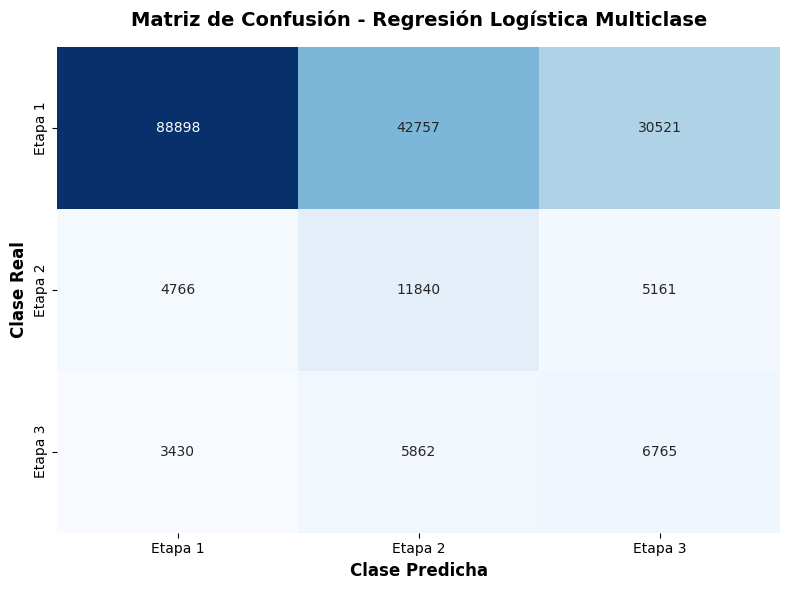

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO: REGRESIÓN LOGÍSTICA MULTICLASE")
print("=" * 60)

# 1. Definición e instanciación del modelo
# - class_weight='balanced': Utiliza los pesos inversos que calculamos (0.41, 3.06, 4.15)
# - multi_class='multinomial': Activa la función Softmax
# - max_iter=1000: Aumentamos el límite de iteraciones para asegurar la convergencia con 800k registros
modelo_lr = LogisticRegression(
    class_weight='balanced', 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)

# 2. Entrenamiento (Ajuste de pesos)
print("Entrenando Regresión Logística (Esto puede tomar unos momentos)...")
modelo_lr.fit(X_train_procesado, y_train)
print("Entrenamiento completado.")

# 3. Predicción sobre el conjunto de prueba
y_pred_lr = modelo_lr.predict(X_test_procesado)


print("\n" + "=" * 60)
print("EVALUACIÓN DEL MODELO BASELINE (TEST SET)")
print("=" * 60)

# 4. Reporte de Clasificación
nombres_clases = [mapeo_inverso[i] for i in range(len(mapeo_inverso))]
print(classification_report(y_test, y_pred_lr, target_names=nombres_clases))

# 5. Visualización de la Matriz de Confusión
matriz_conf = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_conf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    cbar=False
)

plt.title('Matriz de Confusión - Regresión Logística Multiclase', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.ylabel('Clase Real', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación**: Los resultados de la Regresión Logística multiclase reflejan las severas limitaciones de un modelo lineal ante un problema altamente complejo y desbalanceado.

Al aplicar los pesos compensatorios que calculamos previamente (`class_weight='balanced'`), forzamos al modelo a prestar atención a la observaciones de la cartera vencida. Sin embargo, esto provocó una caída drástica en el Accuracy global (del 81% esperado por la clase mayoritaria a solo un 54%).
Al revisar el Recall, observamos el verdadero desempeño: El modelo logra identificar apenas el 42% de los créditos en Etapa 3, po lo que hay una cantidad alta de Falsos Negativos. E inclusive para lograr esto, sacrifica enormemente la Etapa 1, prediciendo erróneamente que miles de créditos sanos están en mora (Precision de Etapa 3 de solo 0.16).

Las fronteras de decisión de este portafolio hipotecario claramente no son linealmente separables. La regresión logística no tiene la capacidad matemática para capturar las interacciones abstractas entre la demografía y las métricas financieras (por ejemplo, cómo interactúa ser un joven en el sector privado con una tasa del 12%). Para superar un Recall del 42% en cartera vencida y reducir los Falsos Positivos, necesitamos un modelo más avanzado de aproximación de funciones: una Red Neuronal.


# 4. Red Neuronal Multicapa (MLP) con PyTorch
## 4.1. Elección y justificación
Antes de adentrarnos en la programación del modelo, se justificará nuestras decisión de arquitectura y de framework. Para los modelos de aprendizaje automático, la elección de la herramienta debe adecuarse a la naturaleza de los datos y los objetivos del negocio.

### Redes Neuronales sobre otros modelos supervisados
A continuación, recordaremos la comparativa de los principales paradigmas de clasificación supervisada aplicables a este portafolio:
| Familia de Algoritmos | Ejemplos | Ventajas | Limitaciones |
| - | - | - | - |
| Modelos Lineales      | Regresión Logística, SVM (Kernel Lineal) | Alta interpretabilidad, bajo costo computacional, matemáticamente estables.                                                                                  | Incapaces de capturar relaciones no lineales sin ingeniería de características manual. Bajo rendimiento en problemas complejos.                       |
| Ensambles de Árboles  | Random Forest, XGBoost, LightGBM         | Robustos ante valores atípicos y datos no escalados. Excelente rendimiento "fuera de la caja". Capacidad de explicar la importancia de variables (SHAP).     | Pueden sufrir para extrapolar fuera del dominio de entrenamiento. Consumen excesiva memoria RAM con matrices muy dispersas (One-Hot masivos).         |
| Aprendizaje Profundo  | Red Neuronal Multicapa (MLP)             | Aproximación Universal (pueden modelar cualquier función continua). Altamente escalables con GPU. Flexibilidad absoluta en la función de pérdida. | Requieren preprocesamiento estricto (escalamiento). Son "cajas negras" (baja interpretabilidad directa). Propensas al sobreajuste si hay pocos datos. |

Tal como mencionamos al principio, hemos seleccionado una Red Neuronal Multicapa (MLP) por dos razones críticas del proyecto:
* Volumen de Datos: El principal problema de las redes neuronales es el sobreajuste (overfitting) en muestras pequeñas. Sin embargo, con nuestra muestra de 800,000 registros de entrenamiento, tenemos la cantidad de datos adecuada para que la red neuronal generalice los patrones sin memorizar el ruido.
* Complejidad del Riesgo: El riesgo crediticio es inherentemente no lineal. Una tasa del 15% puede ser segura para un empleado del sector público de 50 años, pero negativa para un joven del sector privado. Las capas ocultas del MLP y sus funciones de activación (como ReLU) están diseñadas matemáticamente para descubrir estas interacciones complejas de forma automática, algo que a la Regresión Logística le fue imposible lograr (como vimos en su bajo Recall).

### PyTorch sobre otros frameworks
Para implementar la Red Neuronal, recordaremos la comparativa de los distintos frameworks conocidos:
| Framework | Ventajas | Limitaciones |
| - | - | - |
| scikit-learn | Implementación sencilla (métodos .fit() y .predict()). Integración nativa con nuestros Pipelines de preprocesamiento.                                                            | No soporta aceleración por GPU. No permite personalizar la arquitectura interna, cambiar iteraciones del ciclo de entrenamiento, ni modificar a fondo la función de pérdida. |
| JAX | Velocidad de ejecución insuperable gracias a su compilación XLA (Accelerated Linear Algebra). Ideal para investigación matemática pura y cálculo de gradientes a nivel microscópico. | Paradigma funcional estricto (no maneja estados mutables). Curva de aprendizaje muy pronunciada y ecosistema de capas neuronales (como Flax o Haiku) aún fragmentado.        |
| PyTorch | Grafo computacional dinámico. Paradigma Orientado a Objetos (clase nn.Module) muy intuitivo. Estándar en la industria.                        | Requiere escribir el ciclo de entrenamiento de forma manual paso a paso, lo que aumenta la cantidad de código.                                               |

Se elige PyTorch por ofrecer un equilibrio entre control absoluto y legibilidad. A diferencia de scikit-learn, PyTorch nos permite acelerar el entrenamiento utilizando GPUs (útil para nuestro dataset de 800k filas $\times$ 71 columnas) e integrar nuestros pesos de clase personalizados directamente en el cálculo del tensor de costo (CrossEntropyLoss). Aunque JAX es más rápido teóricamente, el diseño orientado a objetos de PyTorch hace que el código sea mucho más estructurado y comprensible.

## 4.2. Estrategia de Validación para Deep Learning
A diferencia de los modelos lineales clásicos como la Regresión Logística, las Redes Neuronales Profundas son aproximadores universales de funciones altamente propensos al sobreajuste (overfitting). Si evaluamos las decisiones de hiperparámetros (como la tasa de aprendizaje o el número de épocas) basándonos únicamente en la pérdida del conjunto de entrenamiento, corremos el riesgo de que la red "memorice" el ruido de los datos en lugar de aprender el patrón oculto.

Por otro lado, utilizar el conjunto de prueba (`X_test`) para monitorear el entrenamiento iterativamente constituye un error metodológico grave que resulta en fuga de datos (Data Leakage). El conjunto de prueba debe permanecer absolutamente "ciego" y utilizarse una única vez en un dataset final.

Para resolver esto, implementaremos una partición de tres conjuntos. Tomaremos nuestro conjunto de entrenamiento actual (que representa el 80% del total) y extraeremos un subconjunto interno de **Validación**. Este nuevo conjunto actuará como un evaluador imparcial durante el ciclo de entrenamiento (Epoch a Epoch), permitiéndonos observar la verdadera capacidad de generalización del modelo sin comprometer el conjunto de prueba final.

In [3]:
from sklearn.model_selection import train_test_split

print("=" * 60)
print("CREACIÓN DEL CONJUNTO DE VALIDACIÓN (DEEP LEARNING)")
print("=" * 60)

# Utilizaremos las matrices X_train_procesado y y_train que ya generamos
# en el Capítulo 2 (las cuales ya tienen el RobustScaler y OneHotEncoder aplicados).
# Extraeremos el 20% de este conjunto para Validación, manteniendo la estratificación.

X_train_final, X_val_procesado, y_train_final, y_val = train_test_split(
    X_train_procesado, 
    y_train, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_train
)

print(f"Dimensiones de Entrada (X_train_procesado original): {X_train_procesado.shape[0]:,} registros")
print("-" * 60)
print(f" -> Nuevo Conjunto de Entrenamiento (X_train_final): {X_train_final.shape[0]:,} registros")
print(f" -> Nuevo Conjunto de Validación  (X_val_procesado): {X_val_procesado.shape[0]:,} registros")
print(f" -> Conjunto de Prueba Intacto    (X_test_procesado): {X_test_procesado.shape[0]:,} registros")
print("-" * 60)

# Validación rápida de la distribución en el nuevo set de entrenamiento
distribucion_train = pd.Series(y_train_final).value_counts(normalize=True) * 100
distribucion_val = pd.Series(y_val).value_counts(normalize=True) * 100

print("\nValidación de Estratificación (Etapa 3 - Cartera Vencida):")
print(f"Proporción en Train: {distribucion_train.get(2, 0):.2f}%")
print(f"Proporción en Val:   {distribucion_val.get(2, 0):.2f}%")

CREACIÓN DEL CONJUNTO DE VALIDACIÓN (DEEP LEARNING)
Dimensiones de Entrada (X_train_procesado original): 800,000 registros
------------------------------------------------------------
 -> Nuevo Conjunto de Entrenamiento (X_train_final): 640,000 registros
 -> Nuevo Conjunto de Validación  (X_val_procesado): 160,000 registros
 -> Conjunto de Prueba Intacto    (X_test_procesado): 200,000 registros
------------------------------------------------------------

Validación de Estratificación (Etapa 3 - Cartera Vencida):
Proporción en Train: 8.03%
Proporción en Val:   8.03%


## 4.3. Tensores y Preparación de Datos (DataLoaders)
El bloque de construcción fundamental en PyTorch es el Tensor (una matriz multidimensional optimizada para cálculos en paralelo, típicamente ejecutada en tarjetas gráficas o GPUs).
Para entrenar nuestra Red Neuronal, no le pasaremos los 640,000 registros de entrenamiento de golpe, ya que esto saturaría la memoria de video (VRAM) y haría que el descenso de gradiente fuera ineficiente.

En su lugar, utilizaremos el concepto de Mini-Batch Gradient Descent. Empaquetaremos nuestros datos en lotes (batches) para procesarlos paulatinamente; por ejemplo, de 1024 registros a la vez. PyTorch gestiona esta carga de memoria a través de dos clases fundamentales:
1. `TensorDataset`: Empareja nuestra matriz de características $X$ con sus respectivas etiquetas $Y$.
2. `DataLoader`: Un iterador que mezcla los datos aleatoriamente (`shuffle=True`) y los sirve en lotes predefinidos durante cada iteración del entrenamiento.

A continuación, convertiremos nuestras matrices de NumPy a tensores nativos de PyTorch, creando los iteradores para nuestros tres subconjuntos: Entrenamiento, Validación y Prueba. Además, configuraremos la detección dinámica del dispositivo de cómputo (CPU o GPU) para garantizar la portabilidad del código y máxima velocidad de ejecución.

In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

print("=" * 60)
print("PREPARACIÓN DE TENSORES PARA PYTORCH")
print("=" * 60)

# 1. Detección dinámica del dispositivo (GPU: CUDA/MPS, o CPU)
# if torch.cuda.is_available():
#    device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#    device = torch.device("mps")  # Soporte para procesadores Apple Silicon (M1/M2/M3)
# else:
#    device = torch.device("cpu")

device = torch.device("cpu")

print(f"Dispositivo de cómputo detectado y asignado: {device}")

# 2. Conversión de las matrices NumPy a Tensores de PyTorch
# Variables de entrada (X): float32 exigido por los pesos de la red
X_train_tensor = torch.tensor(X_train_final.astype(np.float32))
X_val_tensor = torch.tensor(X_val_procesado.astype(np.float32))
X_test_tensor = torch.tensor(X_test_procesado.astype(np.float32))

# Etiquetas objetivo (Y): int64 (long) exigido por la función CrossEntropyLoss
y_train_tensor = torch.tensor(y_train_final, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"\nDimensiones Tensor X_train: {X_train_tensor.shape}, Tipo: {X_train_tensor.dtype}")
print(f"Dimensiones Tensor y_train: {y_train_tensor.shape}, Tipo: {y_train_tensor.dtype}")

# 3. Creación de Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 4. Creación de DataLoaders
# 1024 es un tamaño de lote óptimo para equilibrar velocidad y estabilidad del gradiente en datos tabulares
BATCH_SIZE = 1024

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True # Mezclamos exclusivamente el entrenamiento para evitar sesgos de orden
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False # No se necesita mezclar para la evaluación
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False # No se necesita mezclar para la prueba final
)

print(f"\nNúmero de lotes (batches) por iteración:")
print(f" -> Entrenamiento: {len(train_loader)}")
print(f" -> Validación:    {len(val_loader)}")

PREPARACIÓN DE TENSORES PARA PYTORCH
Dispositivo de cómputo detectado y asignado: cpu

Dimensiones Tensor X_train: torch.Size([640000, 71]), Tipo: torch.float32
Dimensiones Tensor y_train: torch.Size([640000]), Tipo: torch.int64

Número de lotes (batches) por iteración:
 -> Entrenamiento: 625
 -> Validación:    157


**Interpretación**: Los tensores han sido creados y empaquetados exitosamente. Nuestro conjunto de entrenamiento se ha dividido en 625 lotes de 1024 registros cada uno, mientras que el de validación utilizará 157 lotes. Esto optimizará el uso de memoria (RAM/CPU) garantizando una actualización de gradientes más estable. La detección dinámica asignó el procesamiento al CPU.

## 4.4. Arquitectura de la Red
En PyTorch, las redes neuronales se construyen mediante la Programación Orientada a Objetos, heredando de la clase base `nn.Module`. Esta arquitectura será un Perceptrón Multicapa (MLP) profundo, diseñado para capturar la no linealidad del riesgo crediticio:
* Capa de Entrada: Recibirá un vector $x \in \mathbb{R}^{71}$.
* Capas Ocultas: Implementaremos dos capas. Para permitir que la red aprenda funciones complejas, aplicaremos el estándar que es la función de activación no lineal ReLU (Rectified Linear Unit), definida como $f(x) = \max(0, x)$, porque previene el problema del desvanecimiento del gradiente.
* Regularización (Dropout): Para evitar que nuestra red memorice los registros y evitar el sobreajuste, aplicaremos la técnica de regularizacion Dropout. Durante el entrenamiento, estas capas "apagarán" aleatoriamente un porcentaje de neuronas (ej. 30%), obligando a la red a distribuir el aprendizaje y volverse robusta.
* Capa de Salida: Una capa lineal que proyectará la información a un vector de 3 dimensiones (las 3 etapas de riesgo).

No aplicaremos explícitamente la función Softmax en esta capa, ya que PyTorch optimiza el cálculo numérico combinando `LogSoftmax` y la Pérdida de Logaritmo Negativo en una sola función matemática (`CrossEntropyLoss`).

## 4.5. Función de Pérdida y Optimizador
Para que la red aprenda, necesitamos cuantificar qué tan equivocadas son sus predicciones.

* **Función de costo o pérdida**: Utilizaremos la Entropía Cruzada Categórica. Aquí es donde inyectamos nuestro tratamiento para el desbalance de clases. Pasaremos nuestro vector de pesos inversos $w = [0.41, 3.06, 4.15]$ directamente a la función de pérdida. Si el modelo se equivoca al predecir la Etapa 3 (cuyo peso es 4.15), el gradiente de error será masivo, obligando a los pesos de la red a corregir drásticamente.

* **Optimizador**: Seleccionamos Adam (Adaptive Moment Estimation). A diferencia del Descenso de Gradiente Estocástico (SGD) tradicional, Adam adapta dinámicamente la tasa de aprendizaje (learning rate) para cada peso individual calculando momentos de primer y segundo orden, logrando una convergencia mucho más rápida y estable.

In [6]:
import torch.nn as nn
import torch.optim as optim

print("=" * 60)
print("1. DEFINICIÓN DE LA ARQUITECTURA (MLP)")
print("=" * 60)

class RiesgoHipotecarioMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(RiesgoHipotecarioMLP, self).__init__()
        
        # Arquitectura de la red
        self.capa_oculta_1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3) # Apaga el 30% de las neuronas
        
        self.capa_oculta_2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)
        
        self.capa_salida = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Flujo matemático de los tensores (Forward Pass)
        x = self.capa_oculta_1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.capa_oculta_2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        # Salida en crudo (logits). La función de pérdida aplicará el Softmax.
        out = self.capa_salida(x)
        return out

# Instanciamos el modelo y lo enviamos al dispositivo dinámico (CPU o GPU)
input_dim = X_train_procesado.shape[1] # 71
num_classes = 3
modelo_mlp = RiesgoHipotecarioMLP(input_dim, num_classes).to(device)

print(modelo_mlp)
print(f"\nDispositivo del modelo: {next(modelo_mlp.parameters()).device}")


print("\n" + "=" * 60)
print("2. CONFIGURACIÓN DEL OPTIMIZADOR Y PÉRDIDA")
print("=" * 60)

# Convertimos nuestro arreglo de pesos calculados en scikit-learn a un Tensor de PyTorch
# y lo enviamos a la memoria del dispositivo correspondiente
pesos_tensor = torch.tensor(pesos_clases, dtype=torch.float32).to(device)

# Función de costo con los pesos de compensación para el desbalance
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)

# Optimizador Adam con una tasa de aprendizaje (Learning Rate) fija a 0.001
optimizador = optim.Adam(modelo_mlp.parameters(), lr=0.001)

print("Criterio: CrossEntropyLoss (Balanceado)")
print("Optimizador: Adam (lr=0.001)")

1. DEFINICIÓN DE LA ARQUITECTURA (MLP)
RiesgoHipotecarioMLP(
  (capa_oculta_1): Linear(in_features=71, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (capa_oculta_2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (capa_salida): Linear(in_features=64, out_features=3, bias=True)
)

Dispositivo del modelo: cpu

2. CONFIGURACIÓN DEL OPTIMIZADOR Y PÉRDIDA
Criterio: CrossEntropyLoss (Balanceado)
Optimizador: Adam (lr=0.001)


## 4.6. Ciclo de Entrenamiento
A diferencia de scikit-learn, PyTorch requiere que programemos el algoritmo de entrenamiento explícitamente. Por cada "época" (una iteración completa sobre todos los datos), ejecutaremos dos fases fundamentales:

1. **Fase de Entrenamiento**: Ejecutaremos los siguientes pasos matemáticos por cada lote (batch) de 1024 registros:
   * Limpiar los gradientes de la iteración anterior (`zero_grad()`).
   * Forward Pass: Pasar los datos por la red para obtener predicciones.
   * Calcular el error (`loss`) comparando la predicción con la etiqueta real mediante la Entropía Cruzada.
   * Backward Pass: Calcular las derivadas parciales del error respecto a cada peso mediante la regla de la cadena matemática (`backward()`).
   * Actualizar los pesos moviéndolos en la dirección opuesta al gradiente (`step()`).

2. **Fase de Validación**: Al final de cada época, la red dejará de aprender temporalmente. Desactivaremos el motor de gradientes (`torch.no_grad()`) y las capas de regularización como el Dropout (`eval()`) para evaluar el modelo sobre los 160,000 registros de nuestro conjunto de validación. 

Monitorear simultáneamente la pérdida de entrenamiento (Train Loss) y la pérdida de validación (Val Loss) nos permitirá observar la verdadera capacidad de generalización del modelo. Si la pérdida de entrenamiento baja pero la de validación se estanca o sube, sabremos de inmediato que la red está memorizando el ruido (sobreajuste).

In [7]:
import time

print("=" * 60)
print("3. INICIO DEL ENTRENAMIENTO Y VALIDACIÓN")
print("=" * 60)

# Hiperparámetro: Número de pasadas completas sobre todo el dataset
EPOCHS = 30

tiempo_inicio = time.time()

for epoch in range(EPOCHS):
    
    # ==========================================
    # FASE DE ENTRENAMIENTO
    # ==========================================
    # Ponemos el modelo en modo entrenamiento (activa el comportamiento del Dropout)
    modelo_mlp.train() 
    perdida_acumulada_train = 0.0
    
    # Iteramos sobre los lotes de entrenamiento
    for batch_X, batch_y in train_loader:
        # Movemos los datos a la memoria del dispositivo (CPU/GPU)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        # 1. Limpiar gradientes
        optimizador.zero_grad()
        
        # 2. Forward pass (Predicción)
        predicciones = modelo_mlp(batch_X)
        
        # 3. Calcular la pérdida
        loss = criterio(predicciones, batch_y)
        
        # 4. Backward pass (Cálculo de gradientes)
        loss.backward()
        
        # 5. Optimización (Actualización de pesos)
        optimizador.step()
        
        perdida_acumulada_train += loss.item()
        
    perdida_media_train = perdida_acumulada_train / len(train_loader)
    
    # ==========================================
    # FASE DE VALIDACIÓN
    # ==========================================
    # Ponemos el modelo en modo evaluación (desactiva Dropout)
    modelo_mlp.eval()
    perdida_acumulada_val = 0.0
    
    # Apagamos el motor de gradientes para ahorrar memoria y procesamiento
    with torch.no_grad():
        for batch_X_val, batch_y_val in val_loader:
            batch_X_val, batch_y_val = batch_X_val.to(device), batch_y_val.to(device)
            
            predicciones_val = modelo_mlp(batch_X_val)
            loss_val = criterio(predicciones_val, batch_y_val)
            
            perdida_acumulada_val += loss_val.item()
            
    perdida_media_val = perdida_acumulada_val / len(val_loader)
    
    # ==========================================
    # REPORTE DE LA ÉPOCA
    # ==========================================
    print(f"Época [{epoch+1:02d}/{EPOCHS}] | Train Loss: {perdida_media_train:.4f} | Val Loss: {perdida_media_val:.4f}")

tiempo_total = time.time() - tiempo_inicio
print(f"\n[ÉXITO] Entrenamiento y validación finalizados en {tiempo_total:.2f} segundos.")

3. INICIO DEL ENTRENAMIENTO Y VALIDACIÓN
Época [01/30] | Train Loss: 0.9798 | Val Loss: 0.9512
Época [02/30] | Train Loss: 0.9508 | Val Loss: 0.9383
Época [03/30] | Train Loss: 0.9421 | Val Loss: 0.9313
Época [04/30] | Train Loss: 0.9356 | Val Loss: 0.9259
Época [05/30] | Train Loss: 0.9313 | Val Loss: 0.9247
Época [06/30] | Train Loss: 0.9289 | Val Loss: 0.9231
Época [07/30] | Train Loss: 0.9265 | Val Loss: 0.9196
Época [08/30] | Train Loss: 0.9249 | Val Loss: 0.9185
Época [09/30] | Train Loss: 0.9231 | Val Loss: 0.9165
Época [10/30] | Train Loss: 0.9214 | Val Loss: 0.9149
Época [11/30] | Train Loss: 0.9201 | Val Loss: 0.9134
Época [12/30] | Train Loss: 0.9185 | Val Loss: 0.9130
Época [13/30] | Train Loss: 0.9177 | Val Loss: 0.9118
Época [14/30] | Train Loss: 0.9171 | Val Loss: 0.9108
Época [15/30] | Train Loss: 0.9165 | Val Loss: 0.9107
Época [16/30] | Train Loss: 0.9155 | Val Loss: 0.9104
Época [17/30] | Train Loss: 0.9146 | Val Loss: 0.9096
Época [18/30] | Train Loss: 0.9138 | Val 

**Interpretación**: Al observar simultáneamente la pérdida de entrenamiento y la de validación, podemos confirmar en la robustez de nuestra red.

* Ausencia de Sobreajuste (Overfitting): La métrica más crítica aquí es que la pérdida de validación (Val Loss) desciende a la par que la pérdida de entrenamiento y se estabiliza alrededor de 0.9053. En ningún momento observamos una divergencia en forma de "U" (donde la pérdida de entrenamiento sigue bajando, pero la de validación comienza a subir abruptamente), lo cual es indicador de que la red está memorizando el ruido.

* El efecto del Dropout: Es notable que la pérdida de validación sea consistentemente un poco más baja o igual a la de entrenamiento. Esto es un comportamiento normal y esperado en PyTorch debido al Dropout. Durante el entrenamiento, la red está perdiendo el 30% de sus neuronas aleatoriamente, lo que eleva el error artificialmente. Durante la validación, el modelo utiliza el 100% de su capacidad predictiva (eval()), resultando en una evaluación más limpia y precisa.

* Convergencia: Las ligeras oscilaciones en las últimas cinco épocas indican que el optimizador Adam ha encontrado un valle (mínimo local) bastante estable en el espacio hiperdimensional de la función de costo.

Con la certeza de que nuestro modelo ha generalizado correctamente los patrones del riesgo crediticio y no se ha sobreajustado, el estado actual de los pesos es óptimo. Ahora, procederemos a evaluar este modelo contra el conjunto de prueba (X_test), el cual se ha mantenido absolutamente aislado hasta este momento.

# 5. Evaluación Final e Interpretación del Modelo
## 5.1. Evaluación del MLP
El verdadero valor de un modelo predictivo no reside en su capacidad para minimizar el error sobre los datos que ya conoce, sino en su habilidad para generalizar patrones sobre datos completamente nuevos e invisibles.

Para evaluar de manera definitiva nuestra Red Neuronal Multicapa, ejecutaremos el conjunto de prueba (`test_loader`) a través del grafo computacional. Cambiaremos el estado del modelo con el método `.eval()`, el cual desactiva las capas de regularización estocástica (como el Dropout), asegurando que la red utilice el 100% de sus conexiones neuronales aprendidas para emitir una predicción.

Adicionalmente, utilizaremos el contexto gestor `torch.no_grad()` para apagar el motor de diferenciación automática (Autograd). Puesto que no vamos a actualizar los pesos, no calcularemos gradientes, lo que ahorra significativamente consumo de memoria y acelera la inferencia.

EVALUACIÓN DE LA RED NEURONAL (CONJUNTO DE PRUEBA INTACTO)
Inferencia completada exitosamente.

REPORTE DE CLASIFICACIÓN (PYTORCH MLP)
              precision    recall  f1-score   support

     Etapa 1       0.94      0.55      0.70    162176
     Etapa 2       0.21      0.62      0.31     21767
     Etapa 3       0.21      0.52      0.30     16057

    accuracy                           0.56    200000
   macro avg       0.45      0.56      0.43    200000
weighted avg       0.80      0.56      0.62    200000



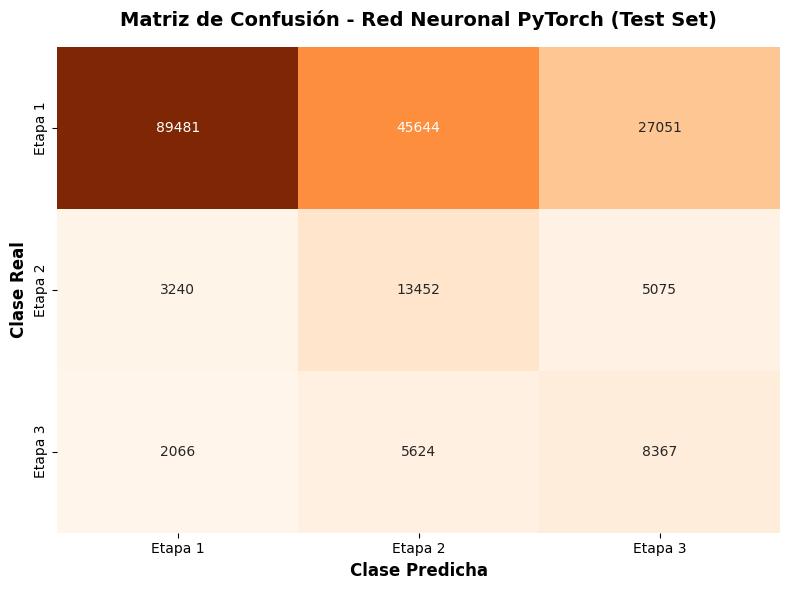

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("EVALUACIÓN DE LA RED NEURONAL (CONJUNTO DE PRUEBA INTACTO)")
print("=" * 60)

# 1. Preparación para inferencia
modelo_mlp.eval() # Desactiva Dropout

predicciones_lista = []
etiquetas_reales_lista = []

# 2. Inferencia sin cálculo de gradientes
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Movemos al dispositivo dinámicamente
        batch_X = batch_X.to(device)
        
        # Forward pass (Predicción)
        logits = modelo_mlp(batch_X)
        
        # Obtener la clase predicha (índice con el valor máximo en la salida)
        # argmax colapsa las 3 probabilidades en la decisión final (0, 1 o 2)
        _, prediccion_batch = torch.max(logits, dim=1)
        
        # Movemos los resultados de vuelta a la memoria principal (CPU) como arreglos NumPy
        predicciones_lista.extend(prediccion_batch.cpu().numpy())
        etiquetas_reales_lista.extend(batch_y.cpu().numpy())

print("Inferencia completada exitosamente.\n")


print("=" * 60)
print("REPORTE DE CLASIFICACIÓN (PYTORCH MLP)")
print("=" * 60)

# 3. Métricas de Clasificación
# Usamos el mapeo inverso que definimos en el preprocesamiento para las etiquetas
nombres_clases = [mapeo_inverso[i] for i in range(len(mapeo_inverso))]
print(classification_report(etiquetas_reales_lista, predicciones_lista, target_names=nombres_clases))

# 4. Visualización de la Matriz de Confusión
matriz_conf_mlp = confusion_matrix(etiquetas_reales_lista, predicciones_lista)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_conf_mlp, 
    annot=True, 
    fmt='d', 
    cmap='Oranges', # Usamos otro color para diferenciarlo de la Regresión Logística
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    cbar=False
)

plt.title('Matriz de Confusión - Red Neuronal PyTorch (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.ylabel('Clase Real', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación**: Los resultados sobre nuestro conjunto de prueba confirman que la red neuronal generaliza la detección de riesgo mucho mejor que la regresión logística, validando el éxito de nuestro entrenamiento con partición Train-Validation-Test.

* Mientras que la línea base apenas detectaba el 42% de la Etapa 3 y el 54% de la Etapa 2, nuestro MLP ha elevado estas cifras al 52% y 62% respectivamente.
* En la Etapa 3, tenemos 16,057 créditos en el set de prueba. La regresión logística (42%) habría detectado aprox 6,743. Nuestra red neuronal (52%) detectó aprox 8,349. Estamos hablando de haber identificado proactivamente más de 1,600 créditos deteriorados adicionales que el modelo lineal dejó pasar como creditos de bajo riesgo (Falsos Negativos). n un portafolio donde la mediana del saldo insoluto es de casi 1 millón MXN, estamos hablando de haber detectado proactivamente más de mil millones de pesos en riesgo oculto.
* Como es evidente, la Precision para las Etapas 2 y 3 sigue siendo baja (21%). De cada 5 créditos alertados, 4 son sanos. Sin embargo, comercialmente esta fue la decisión correcta dictada por nuestros `class_weights`: preferimos asumir Falsos Positivos (que solo cuestan el costo de oportunidad temporal de crear reservas preventivas) antes que sufrir Falsos Negativos (que representan impacto directo en utilidades por impago no anticipado).

La red aprendió exitosamente que la frontera del riesgo no es lineal y está protegiendo la liquidez de la institución al maximizar la sensibilidad.

## 5.3. Curva ROC y AUC Multiclase
Para concluir la fase de evaluación, necesitamos analizar la capacidad intrínseca del modelo para separar las tres clases, independientemente del umbral de probabilidad por defecto (0.5) o del efecto visual que causa el desbalance en la matriz de confusión.

Para ello, trazaremos la Curva ROC (Receiver Operating Characteristic) y calcularemos el AUC (Área Bajo la Curva) bajo un esquema One-vs-Rest (clasificación binaria, uno contra todos). A diferencia del Accuracy (que simplemente cuenta aciertos en un corte fijo), el AUC evalúa la capacidad de ranking del modelo: un AUC de 0.75 significa que, si tomamos un crédito aleatorio que sí pertenece a la Etapa 3 y uno que no, hay un 75% de probabilidad de que el modelo asigne un puntaje de riesgo mayor al crédito que realmente está deteriorado.

Un valor de 0.5 indica que el modelo adivina al azar (nula discriminación), mientras que un valor de 1.0 indica separación perfecta. Evaluar el AUC es la forma común para calificar modelos financieros con desbalance de clases.

CÁLCULO DE PROBABILIDADES Y CURVAS ROC-AUC


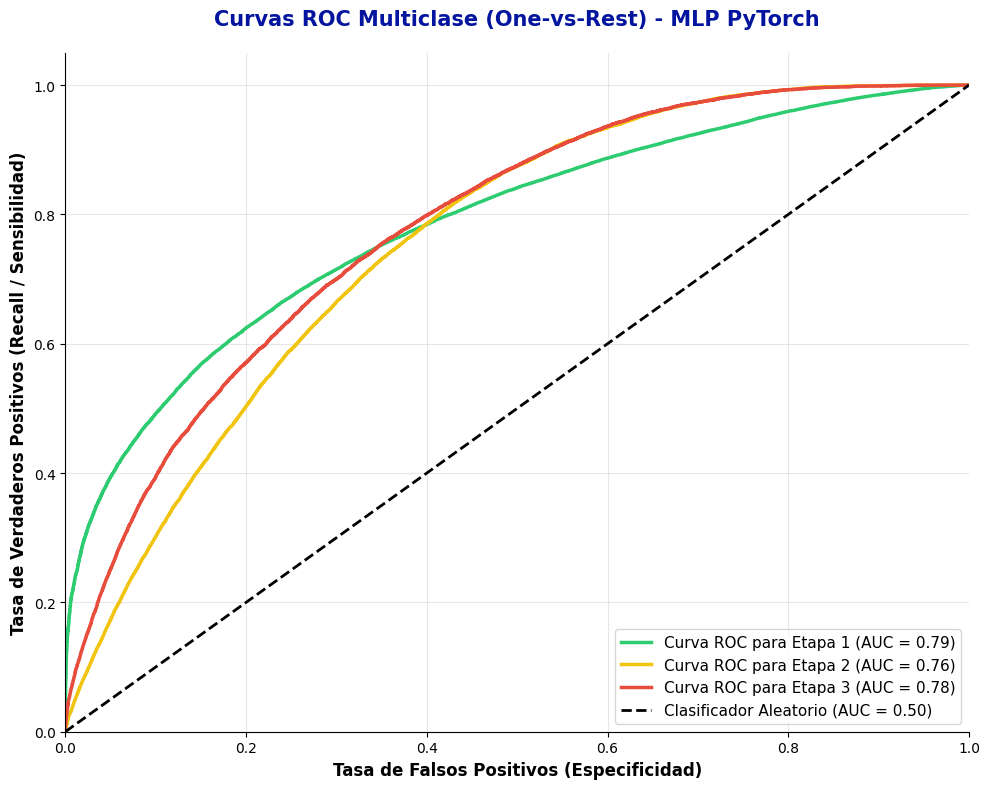

In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

print("=" * 60)
print("CÁLCULO DE PROBABILIDADES Y CURVAS ROC-AUC")
print("=" * 60)

# 1. Binarización de etiquetas reales para el esquema One-vs-Rest (OvR)
# Esto convierte y_test de [0, 1, 2] a matrices binarias: [1,0,0], [0,1,0], [0,0,1]
y_test_binario = label_binarize(y_test, classes=[0, 1, 2])
n_clases = y_test_binario.shape[1]

# 2. Extracción de probabilidades del modelo PyTorch
probabilidades_lista = []

modelo_mlp.eval()
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        logits = modelo_mlp(batch_X)
        
        # Aplicamos la función Softmax para convertir los logits puros a probabilidades (0 a 1)
        probs = F.softmax(logits, dim=1)
        probabilidades_lista.extend(probs.cpu().numpy())

y_score = np.array(probabilidades_lista)

# 3. Cálculo de ROC y AUC por clase
fpr = dict() # Tasa de Falsos Positivos
tpr = dict() # Tasa de Verdaderos Positivos
roc_auc = dict()

for i in range(n_clases):
    fpr[i], tpr[i], _ = roc_curve(y_test_binario[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Visualización
colores = ['#2ecc71', '#f1c40f', '#e74c3c']
plt.figure(figsize=(10, 8))

for i, color in zip(range(n_clases), colores):
    nombre_clase = mapeo_inverso[i]
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'Curva ROC para {nombre_clase} (AUC = {roc_auc[i]:.2f})')

# Línea de referencia (Adivinanza aleatoria)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Especificidad)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=12, fontweight='bold')
plt.title('Curvas ROC Multiclase (One-vs-Rest) - MLP PyTorch', fontsize=15, fontweight='bold', pad=20, color='#03149E')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación**: Las curvas ROC bajo un enfoque binario (One-vs-Rest) demuestran una capacidad discriminativa estable y unificada en todo el espectro de riesgo. El modelo obtuvo un Área Bajo la Curva (AUC) de 0.79 para la Etapa 1, 0.76 para la Etapa 2 y 0.78 para la Etapa 3.

Como vimos, a diferencia del *Accuracy* , el AUC mide la separación matemática del modelo. Un AUC de 0.78 en la Etapa 3 significa que, si tomamos al azar un crédito que realmente cayó en impago y un crédito sano, hay un 78% de probabilidad de que nuestra Red Neuronal le asigne un puntaje de riesgo mayor al crédito malo. La consistencia de estos valores demuestra que el modelo es capaz de aislar el riesgo muy por encima de un clasificador aleatorio (AUC = 0.50) en todas las etapas. 

Sin embargo no hay que perder de vista, que en en el mundo real, predecir el comportamiento humano es inherentemente estocástico, ya que existen factores macroeconómicos e imprevistos personales que ninguna base de datos puede anticipar por completo. De acuerdo con los estándares de la industria (como los descritos por RiskSeal para modelos de Credit Scoring), un AUC entre 0.70 y 0.80 se clasifica como "Aceptable a Bueno".

Alcanzar este nivel de discriminación es un logro técnico considerable. Logramos este desempeño basándonos puramente en demografía estática, características contractuales del producto y masas monetarias, sin requerir variables dinámicas (y costosas) como consultas en tiempo real al buró de crédito o historiales de transaccionalidad interbancaria.